In [99]:
import numpy as np
import pandas as pd
import os, sys, glob, shutil
sys.path.append('../')
import hbn_utils
import hbn_config
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
subject_ids = [f.split('/')[-2] for f in glob.glob('/gpfs/milgram/project/casey/elb77/HBN_Prep/*/')]

In [11]:
smth = '/gpfs/milgram/project/turk-browne/projects/HealthyBrainNetwork/derivatives/afni-smooth'

In [52]:
pheno_df = pd.read_csv(hbn_config.HBN_PARTICIPANT_INFO, delimiter='\t')
pheno_df.head()

,participant_id,study,study_site,session_id,wave,age,sex,bmi,ethnicity,race,handedness,participant_education,parent_1_education,parent_2_education,p_factor_mcelroy_harmonized_all_samples,internalizing_mcelroy_harmonized_all_samples,externalizing_mcelroy_harmonized_all_samples,attention_mcelroy_harmonized_all_samples,cubids_acquisition_group
0,NDARAA075AMK,HBN,HBNsiteSI,HBNsiteSI,1,6.728040,Female,14.858469,NaN,NaN,Right,1st Grade,Complete tertiary,Complete tertiary,-1.608375,-0.744118,-0.314187,-0.432662,142
1,NDARAA112DMH,HBN,HBNsiteRU,HBNsiteRU,1,5.545744,Male,15.412484,Hispanic or Latino,NaN,Right,Kindergarten,Complete primary,Complete tertiary,-0.030279,0.028632,2.267127,0.847370,53
2,NDARAA117NEJ,HBN,HBNsiteRU,HBNsiteRU,1,7.475929,Male,17.205673,Hispanic or Latino,NaN,Right,2nd Grade,No/incomplete primary,Complete primary,0.457273,-0.916688,0.000607,0.786328,53
3,NDARAA306NT2,HBN,HBNsiteRU,HBNsiteRU,1,21.216746,Female,30.722843,not Hispanic or Latino,Other,Right,Some College,Complete secondary,Complete tertiary,1.308340,1.711578,-1.089480,-0.678680,5
4,NDARAA504CRN,HBN,HBNsiteCBIC,HBNsiteCBIC,1,9.165297,Female,16.511573,Hispanic or Latino,Other,Right,3rd Grade,NaN,Complete tertiary,-0.056069,1.862768,0.191283,0.094519,7


In [53]:
info = pd.DataFrame(columns=['subject_id', 'movie_FD', 'rest_FD', 'fmriprep_done', 'cleaning_done', 'age', 'sex','AgeGroup1',
                            'session'])
for sub in subject_ids:
    cleaning_done=0
    fmriprep_done=0
    
    try: fdR =  hbn_utils.fmriprep_confounds_mean_fd(sub, 'rest')
    except: fdR=np.nan

    try: fdTP =  hbn_utils.fmriprep_confounds_mean_fd(sub, 'movieTP')
    except: fdTP=np.nan

    if fdTP + fdR > 0:
        fmriprep_done = 1
    
    restFN=glob.glob(f'{smth}/{sub}/func/*task-rest*sm6.nii.gz') 
    movFN=glob.glob(f'{smth}/{sub}/func/*task-movieTP*sm6.nii.gz')
    if len(restFN) + len(movFN) >= 2: cleaning_done=1

    try:
        age = pheno_df[pheno_df['participant_id'] == sub.replace('sub-','')]['age'].item()
    except:
        age=np.nan
    try:
        sex = pheno_df[pheno_df['participant_id'] == sub.replace('sub-','')]['sex'].item()
    except:
        sex=np.nan

    try:
        ses = pheno_df[pheno_df['participant_id'] == sub.replace('sub-','')]['session_id'].item()
    except:
        ses=np.nan

    if age < 8:
        ageGroup = 'U08'
    elif age < 9:
        ageGroup='U09'
    elif age < 10:
        ageGroup='U10'
    elif age < 11:
        ageGroup = 'U11'
    elif age < 12:
        ageGroup='U12'
    elif age < 13:
        ageGroup = 'U13'
    elif age < 14:
        ageGroup = 'U14'
    elif age < 15:
        ageGroup = 'U15'
    elif age < 16:
        ageGroup = 'U16'
    elif age < 17:
        ageGroup = 'U17'
    elif age < 23:
        ageGroup='U22'
    else:
        ageGroup='Unk'
        print(sub, ageGroup, age)
        
    
    info.loc[len(info)] = {'subject_id':sub, 'movie_FD':fdTP, 'rest_FD':fdR, 'fmriprep_done':fmriprep_done, 
                           'cleaning_done':cleaning_done, 'sex':sex, 'age':age, 'session':ses, 'AgeGroup1':ageGroup }


logs Unk nan
sourcedata Unk nan


In [54]:
info.to_csv('../HBN/basic_cohort_info.csv')

In [46]:
# find which subjects need to be cleaned
subjects_to_rerun = info[(info['fmriprep_done']==1) & (info['cleaning_done']==0) ]['subject_id'].values

with open('../preproc/hbn/joblists/joblist_afni_preproc_continue.txt','w') as f:
    for s in subjects_to_rerun:
        for t in ['rest','movieTP']:
            f.write(f'python -u /gpfs/milgram/project/turk-browne/users/elb77/task_dim/preproc/run_afni_preproc.py -d HBN -s {s} -t {t}\n')
## RERUN AFNI PREPROCESSING 

In [63]:
# write out subjects to run IDE with, including all (some may fail per above) 
subjects_here = info[(info['fmriprep_done']==1)]['subject_id'].values
print(len(subjects_here))
i=0
cmd = 'python -u /gpfs/milgram/project/turk-browne/users/elb77//task_dim//atlas_IDE_methods.py -d hbn '
with open('../joblists/hbn_atlas_ide_joblist.txt', 'w') as f:
    for s in range(len(subjects_here)):
        for t in ['movieTP','rest']:
            f.write(f'{cmd} -i {s} -t {t}\n')
            i+=1
i

543


1086

In [66]:
scr = hbn_config.SCRATCH_DIR+'/HBN/IDE/LOSO_parcel/results/'

In [79]:
info['include_both_tasks'] = ['']*len(info)
for i in info.index:
    s = info.iloc[i]['subject_id']
    if len(glob.glob(f'{scr}/{s}*')) == 6:
        info.at[i,'include_both_tasks'] = 1
    else:
        info.at[i,'include_both_tasks'] = 0
        print(f'none for {s}')

none for sub-NDARVB819ENX
none for sub-NDARZU279XR3
none for sub-NDARZM580BG2
none for sub-NDARAP782TVC
none for sub-NDARPH105ZFF
none for sub-NDARDR950CGG
none for sub-NDARXY240WJC
none for sub-NDARMW178UDD
none for logs
none for sub-NDARZY668NMV
none for sub-NDARZX163EWC
none for sub-NDARYC287UFV
none for sub-NDARZA982YTP
none for sub-NDARWF422UK3
none for sub-NDARYM334BZ5
none for sub-NDARZK732FZ0
none for sub-NDARVG641YGK
none for sub-NDARYM586MYN
none for sub-NDARVY366HWJ
none for sub-NDARZP630WYL
none for sub-NDARVP285RXV
none for sub-NDARYN174NPH
none for sub-NDARYG665JUD
none for sub-NDARYU120NDA
none for sub-NDARNT541VT2
none for sub-NDARWR628EFJ
none for sub-NDARMV718DYL
none for sub-NDARYH603BDN
none for sub-NDARYW945PJU
none for sub-NDARPZ720WKW
none for sub-NDARYW789GNP
none for sub-NDARXH529MTX
none for sub-NDARWF306VWJ
none for sub-NDARWP817CVB
none for sub-NDAREC777ADZ
none for sub-NDARWW005GCU
none for sub-NDARZL113CU0
none for sub-NDARZW363UGM
none for sub-NDARWL656UR

In [83]:
info.to_csv('participants.csv')

In [97]:
info.head()

,subject_id,movie_FD,rest_FD,fmriprep_done,cleaning_done,age,sex,AgeGroup1,session,include_both_tasks
0,sub-NDARUT891XYJ,0.085711,0.071923,1,0,17.586356,Male,U22,HBNsiteCBIC,1
1,sub-NDARLL790WLF,0.881275,0.170710,1,1,7.615103,Female,U08,HBNsiteRU,1
2,sub-NDARCU865PBV,0.099556,0.105246,1,1,10.865046,Male,U11,HBNsiteRU,1
3,sub-NDARTX575YBU,0.288746,0.271796,1,0,7.527948,Male,U08,HBNsiteRU,1
4,sub-NDARKB614KGY,0.085255,0.182518,1,1,10.651380,Female,U11,HBNsiteRU,1


In [101]:
cmd='python -u /gpfs/milgram/project/turk-browne/users/elb77//task_dim/atlas_isc.py -t movieTP -d hbn'
with open('../joblists/hbn_atlas_isc_joblist.txt','w') as f:
    for g in info.AgeGroup1.unique():
        temp=info[(info['include_both_tasks']==1)&(info['AgeGroup1']==g)]
        for i in range(len(temp)):
            f.write(f'{cmd} -i {i} -s {g}\n')

<Axes: xlabel='AgeGroup1', ylabel='sex'>

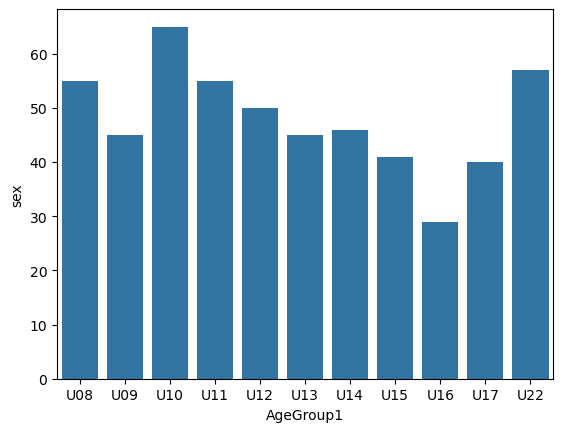

In [98]:
sns.barplot(data=info[info['include_both_tasks']==1].groupby('AgeGroup1').count().reset_index(),
            x='AgeGroup1', y='sex')

In [6]:
# Figure out which subjects are done
rs_done = []
movie_done = []
path='/gpfs/milgram/pi/casey/elb77/HBN_Prep/'
for sub,ses in zip(info.subject_id.values, info.session.values):
    rest_fns = glob.glob(f'{path}/{sub}/ses-{ses}/func/*rest*MNI152*bold.nii.gz')
    movie_fns = glob.glob(f'{path}/{sub}/ses-{ses}/func/*movieTP*MNI152*bold.nii.gz')
    boo = len(rest_fns)>0
    rs_done.append(boo)
    boo = len(movie_fns)>0
    movie_done.append(boo)
    

info['finished_fMRIprep_RS']=rs_done
info['finished_fMRIprep_Movie']=movie_done
np.sum(rs_done), np.sum(movie_done)  

(529, 530)

In [23]:
# Figure out which subjects are done
rs_done = []
movie_done = []
path='/gpfs/milgram/project/turk-browne/projects/HBN_AFNI/derivatives/afni-smooth/'
new_path = '/gpfs/milgram/project/turk-browne/projects/HealthyBrainNetwork/derivatives/afni-smooth/'
for sub,ses in zip(info.subject_id.values, info.session.values):
    rest_fns = glob.glob(f'{path}/{sub}/func/*rest*MNI152*-clean.nii.gz')
    movie_fns = glob.glob(f'{path}/{sub}/func/*movieTP*MNI152*-clean.nii.gz')
    boo = len(rest_fns)>0
    if boo:
        new_dn = f'{new_path}/{sub}/func/'
        os.makedirs(new_dn, exist_ok=True)
        files_to_copy = glob.glob(f'{path}/{sub}/func/*rest*')
        for fn in files_to_copy:
            bn=os.path.basename(fn)
            new_fn = f'{new_dn}/{bn}'
            shutil.copy(fn, new_fn)
        print(f'copied {len(files_to_copy)} for {sub} rest')

    boo = len(movie_fns)>0
    if boo:
        files_to_copy = glob.glob(f'{path}/{sub}/func/*movieTP*')
        for fn in files_to_copy:
            bn=os.path.basename(fn)
            new_fn = f'{new_dn}/{bn}'
            shutil.copy(fn, new_fn)
        print(f'copied {len(files_to_copy)} for {sub} movie')


copied 4 for sub-NDARDC987BMU rest
copied 4 for sub-NDARGJ395FKP rest
copied 4 for sub-NDARJM828PAL rest
copied 4 for sub-NDARKG859AGN rest
copied 4 for sub-NDARNE758RD6 rest
copied 4 for sub-NDARNK740ZVM rest
copied 4 for sub-NDARNN142WYB rest
copied 4 for sub-NDARNN218UGY rest
copied 4 for sub-NDARNX223DY3 rest
copied 4 for sub-NDARNY205RK8 rest
copied 4 for sub-NDARPE830YU0 rest
copied 4 for sub-NDARPL479LHN rest
copied 4 for sub-NDARPV009TYX rest
copied 4 for sub-NDARPV412JEN rest
copied 4 for sub-NDARPX219TW0 rest
copied 4 for sub-NDARRB359CRR rest
copied 4 for sub-NDARRB942UWU rest
copied 4 for sub-NDARRL315KV3 rest
copied 4 for sub-NDARRP801AX1 rest
copied 4 for sub-NDARRU290EZV rest
copied 4 for sub-NDARRU499DP2 rest
copied 4 for sub-NDARRU729XRU rest
copied 4 for sub-NDARRU979UBW rest
copied 4 for sub-NDARRV002MA8 rest
copied 4 for sub-NDARRV217VTA rest
copied 4 for sub-NDARRV688GUX rest
copied 4 for sub-NDARRV837BZQ rest
copied 4 for sub-NDARRW141HUT rest
copied 4 for sub-NDA

In [25]:
# Figure out which subjects are done
rs_done = []
movie_done = []
path = '/gpfs/milgram/project/turk-browne/projects/HealthyBrainNetwork/derivatives/afni-smooth/'
for sub,ses in zip(info.subject_id.values, info.session.values):
    rest_fns = glob.glob(f'{path}/{sub}/func/*rest*MNI152*-clean.nii.gz')
    movie_fns = glob.glob(f'{path}/{sub}/func/*movieTP*MNI152*-clean.nii.gz')
    boo = len(rest_fns)>0
    rs_done.append(boo)
    boo = len(movie_fns)>0
    movie_done.append(boo)
    

info['finished_fMRIprep_RS_clean']=rs_done
info['finished_fMRIprep_Movie_clean']=movie_done
np.sum(rs_done), np.sum(movie_done)  

(429, 404)

In [27]:
info.to_csv('basic_cohort_info.csv')

In [100]:
info.iloc[0]

subject_id            sub-NDARUT891XYJ
movie_FD                      0.085711
rest_FD                       0.071923
fmriprep_done                        1
cleaning_done                        0
age                          17.586356
sex                               Male
AgeGroup1                          U22
session                    HBNsiteCBIC
include_both_tasks                   1
Name: 0, dtype: object

In [36]:
with open('participants_rest_preprocessed.txt','w') as f:
    for i in info.index:
        row=info.iloc[i]
        if row.finished_fMRIprep_RS_clean:
            f.write(row.subject_id+'\n')

In [38]:
with open('participants_movieTP_preprocessed.txt','w') as f:
    for i in info.index:
        row=info.iloc[i]
        if row.finished_fMRIprep_Movie_clean:
            f.write(row.subject_id+'\n')

In [13]:
subjects_to_afni = []
subjects_to_fmriprep = []
for sub in info.subject_id.values:
    row = info[info.subject_id==sub]
    if row.finished_fMRIprep_RS.item():
        if not row.finished_fMRIprep_RS_clean.item():
            subjects_to_afni.append(sub)
    else:
        subjects_to_fmriprep.append(sub)
    

In [26]:
lines =[]
with open('../preproc/hbn/joblists/process_script_joblist_fmriprep.txt', 'r') as f:
    lines = f.read()
subjects = [l.split(' ')[2] for l in lines]

In [18]:
j=0
with open('../preproc/hbn/joblists/process_script_joblist_fmriprep.txt','w') as f:
    for i,(sub,ses) in enumerate(zip(info.subject_id.values, info.session.values)):
        if sub in subjects_to_fmriprep:
            sub=sub[4:]
            cmd = f'bash /gpfs/milgram/project/turk-browne/users/elb77/task_dim/preproc/hbn/process_subjects.sh'
            f.write(f'{cmd} {sub} {ses}\n')
            j+=1
print(j)

152


In [12]:
workdir = '/gpfs/milgram/scratch60/turk-browne/elb77/workdir3'
for i,s in enumerate(info.subject_id.values):
    if rs_done[i]==1:
        if os.path.exists(f'{workdir}/fmriprep_23_2_wf/sub_{s[4:]}_wf/'):
            print(f'deleting {s}')
            shutil.rmtree(f'{workdir}/fmriprep_23_2_wf/sub_{s[4:]}_wf/')
        if os.path.exists(f'{outdir}/sourcedata/freesurfer/{s}/scripts/'):
            shutil.rmtree(f'{outdir}/sourcedata/freesurfer/{s}/scripts/')

deleting sub-NDARAF535XK6
deleting sub-NDARAG115LZP
deleting sub-NDARAP457WB5
deleting sub-NDARAT680GJA
deleting sub-NDARAT982JTU
deleting sub-NDARAU530GLJ
deleting sub-NDARAX277ATU
deleting sub-NDARBH019KPD
deleting sub-NDARBK106KRH
deleting sub-NDARBN365EV3
deleting sub-NDARBP527JWC
deleting sub-NDARCC059WTH
deleting sub-NDARCK647MU6
deleting sub-NDARCM811CV1
deleting sub-NDARDD854GF8
deleting sub-NDAREF164ZUJ
deleting sub-NDAREG013BLG
deleting sub-NDAREK395BM3
deleting sub-NDAREK686WN1
deleting sub-NDARFD316UD2
deleting sub-NDARFD552FRH
deleting sub-NDARFD620BUW
deleting sub-NDARFF061VUK
deleting sub-NDARFG364YMG
deleting sub-NDARFG713PLR
deleting sub-NDARFG851ZNZ
deleting sub-NDARFJ179MG0
deleting sub-NDARFJ494ZDJ
deleting sub-NDARFM211KDJ
deleting sub-NDARFM619GTV
deleting sub-NDARFP503KJF
deleting sub-NDARFP841PDJ
deleting sub-NDARFR445XKP
deleting sub-NDARFT698LLU
deleting sub-NDARFT787HJW
deleting sub-NDARFU916UZY
deleting sub-NDARFV061AR5
deleting sub-NDARFY525TL2
deleting sub

In [16]:
info.to_csv('basic_cohort_info.csv')

In [11]:
# ongoing_run_identifiers = ['20250520-000524_b338827c-ea44-4737-86ed-cde46d01ede5',
#                            '20250520-000524_51974c63-595f-47c6-bdd5-6169613a9b5d']
# ongoing_subjects = ['NDARAP782TVC', 'NDARBM433VER']

workdir = '/gpfs/milgram/scratch60/turk-browne/elb77/workdir3'
bidsdir = '/gpfs/milgram/scratch60/casey/elb77/HBN/HBN_BIDS'
outdir='/gpfs/milgram/project/casey/elb77/HBN_Prep'
license='/home/elb77/license.txt'
prestr = f'module load fmriprep/23.2.1; fmriprep {bidsdir} {outdir} participant --participant-label'

In [17]:
with open('../preproc/hbn/joblists/joblist_afni_preproc.txt', 'w') as f:
    for s in subjects_to_afni:
        for t in ['movieTP', 'rest']:
            f.write(f'python -u /gpfs/milgram/project/turk-browne/users/elb77/task_dim/preproc/run_afni_preproc.py -d HBN -s {s} -t {t}\n')
            
            
            
            
            

In [36]:
# Figure out which subjects have rest but no movie
subs = info[(info['finished_fMRIprep_RS']==True) 
    & (info['finished_fMRIprep_Movie']==False)]['subject_id'].values
print(len(subs))
postr = f'-t movieTP -w  {workdir} --skip_bids_validation --fs-license-file {license} --output-spaces MNI152Lin --nprocs 16  --ignore  fieldmaps t2w'
with open('../preproc/hbn/joblists/joblist_movie_resume.txt','w') as f:
    for s in subs:
        f.write(f'{prestr} {s[4:]} {postr}\n')

12


In [22]:
# Figure out which subjects have movie but no RS 
subs = info[(info['finished_fMRIprep_RS']==False) 
    & (info['finished_fMRIprep_Movie']==True)]['subject_id'].values

postr = f'-t rest -w  {workdir} --skip_bids_validation --fs-license-file {license} --output-spaces MNI152Lin --nprocs 16  --ignore  fieldmaps t2w'

# loop through ongoing runs and get rid of folders 
j=0
for dn in glob.glob(f'{workdir}/202505*'):
    if dn not in ongoing_run_identifiers:
        # Remove the directory and its contents
        shutil.rmtree(dn)
        j+=1
print(f'removed {j} directories')
# make sure no IsRunning
j=0
for s in subs:
    fns2del = glob.glob(f'{outdir}/sourcedata/freesurfer/{s}/scripts/IsRunning*')
    if len(fns2del) > 0 and s not in ongoing_subjects:
         shutil.rmtree(f'{outdir}/sourcedata/freesurfer/{s}/scripts/')
         j+=1
print(f'removed fns from {j}')
# Write these to file
with open('../preproc/hbn/joblists/joblist_rest_resume.txt','w') as f:
    for s in subs:
        f.write(f'{prestr} {s[4:]} {postr}\n')

removed 199 directories


In [86]:
subs = info[(info['finished_fMRIprep_RS']==False) 
    & (info['finished_fMRIprep_Movie']==False)]['subject_id'].values
print(f'{len(subs)} remaining')

533 remaining


In [88]:
postr = f'-w {workdir} --skip_bids_validation --fs-license-file {license} --output-spaces MNI152Lin --nprocs 16 --ignore fieldmaps t2w'

config_file = '/gpfs/milgram/pi/turk-browne/users/elb77/task_dim/preproc/hbn/joblists/bids_config.json'

# Write these to file
with open('../preproc/hbn/joblists/joblist_singletons_rerun.txt','w') as f:
    for s in subs:
        isRun = f'{outdir}/sourcedata/freesurfer/{s}/scripts/IsRunning*'
        wfDir = f'{workdir}/fmriprep_23_2_wf/sub_{s[4:]}_wf'
        f.write(f'rm -rf {isRun} ; {prestr} {s[4:]} {postr} --bids-filter-file {config_file}\n')
        

In [61]:
# Find subjects with neither task nor rest done, only include relevant tasks

# subs = info[(info['finished_fMRIprep_RS']==False) 
#     & (info['finished_fMRIprep_Movie']==False)]['subject_id'].values
# print(f'{len(subs)} remaining')
# running = ["NDARAP782TVC", "NDARAG115LZP", "NDARAT680GJA", "NDARAT982JTU", "NDARAX277ATU", "NDARBM433VER", "NDARBN365EV3"]
# running = [f'sub-{s}' for s in running]
# d=0
# for s in subs:
#     if s not in running and os.path.exists(f'{workdir}/fmriprep_23_2_wf/sub_{s[4:]}_wf'):
#         shutil.rmtree(f'{workdir}/fmriprep_23_2_wf/sub_{s[4:]}_wf')
#         d+=1
# print(f'deleted {d}')

# # make sure no IsRunning
# # j=0
# # for s in subs:
# #     fns2del = glob.glob(f'{outdir}/sourcedata/freesurfer/{s}/scripts/IsRunning*')
# #     if len(fns2del) > 0 and s not in ongoing_subjects:
# #          shutil.rmtree(f'{outdir}/sourcedata/freesurfer/{s}/scripts/')
# #          j+=1
# # print(f'removed IsRunning from {j}')

postr = f'-w {workdir} --skip_bids_validation --fs-license-file {license} --output-spaces MNI152Lin --nprocs 16 --ignore fieldmaps t2w'

config_file = '/gpfs/milgram/pi/turk-browne/users/elb77/task_dim/preproc/hbn/joblists/bids_config.json'

# Write these to file
with open('../preproc/hbn/joblists/joblist_both_tasks_all.txt','w') as f:
    for s in subs:
        if s not in running: 
            isRun = f'{outdir}/sourcedata/freesurfer/{s}/scripts/IsRunning*'
            wfDir = f'{workdir}/fmriprep_23_2_wf/sub_{s[4:]}_wf'
            f.write(f'rm -rf {isRun} ; {prestr} {s[4:]} {postr} --bids-filter-file {config_file} ; rm -rf {wfDir} \n')
            

In [ ]:
subs = info[(info['finished_fMRIprep_RS']==False) 
    & (info['finished_fMRIprep_Movie']==False)]['subject_id'].values
for s in subs[10:]:
    

In [20]:
dn = '/gpfs/milgram/scratch60/turk-browne/jlc279/HBN/preprocessed'
still_not = []
for sub,ses in zip(info.subject_id.values, info.session.values):
    if sub in not_here:
        fmap_path = f'{dn}/{sub}/fmap/*'
        anat_path = f'{dn}/{sub}/anat/*'
        out_path = f'{mydir}/{sub}/ses-{ses}'
        if len(glob.glob(fmap_path)) > 0:
            for f in glob.glob(fmap_path):
                os.makedirs(f'{out_path}/fmap', exist_ok=True)
                shutil.copy(f, f'{out_path}/fmap/')
            for f in glob.glob(anat_path):
                os.makedirs(f'{out_path}/anat', exist_ok=True)
                shutil.copy(f, f'{out_path}/anat')
        else:
            still_not.append(sub)
        
    

In [18]:
dn = '/gpfs/milgram/pi/turk-browne/jlc279/HBN/preprocessed/'
mydir = '/gpfs/milgram/scratch60/turk-browne/elb77/HBN/HBN_BIDS/derivatives/fmriprep/'
not_here = []
for sub,ses in zip(info.subject_id.values, info.session.values):
    fmap_path = f'{dn}/{sub}/fmap/*'
    anat_path = f'{dn}/{sub}/anat/*'
    out_path = f'{mydir}/{sub}/ses-{ses}'
    if len(glob.glob(fmap_path)) > 0:
        continue
        # for f in glob.glob(fmap_path):
        #     os.makedirs(f'{out_path}/fmap', exist_ok=True)
        #     shutil.copy(f, f'{out_path}/fmap/')
        # for f in glob.glob(anat_path):
        #     os.makedirs(f'{out_path}/anat', exist_ok=True)
        #     shutil.copy(f, f'{out_path}/anat')
    else:
        not_here.append(sub)
    

In [12]:
with open('fmriprep_participants.txt','w') as f:
    for s in info.subject_id.values:
        g = s.replace('sub-','')
        f.write(f'{g}\n')

In [23]:
od='/gpfs/milgram/scratch60/turk-browne/elb77/HBN/HBN_BIDS/'
with open('../preproc/pull_datalad_hbn_new.sh','w') as f:
    strings = [f'cd {od}']
    strings += [f'datalad get {s}/ses-{ses}/fmap/*' for s, ses in zip(info.subject_id.values, info.session.values)]

    strings += [f'datalad get {s}/ses-{ses}/fmap/*' for s, ses in zip(info.subject_id.values, info.session.values)]
    strings += [f'datalad get {od}{s}/ses-{ses}/func/*task-rest*' for s, ses in zip(info.subject_id.values, info.session.values)]
    strings += [f'datalad get {od}{s}/ses-{ses}/func/*task-movieTP*' for s, ses in zip(info.subject_id.values, info.session.values)]
    for st in strings:
        f.write(st)
        f.write('\n')
        

        

In [ ]:
# Files to move to turk-browne 



In [4]:
od='/gpfs/milgram/scratch60/turk-browne/elb77/HBN/HBN_BIDS/'
with open('../preproc/pull_datalad_hbn_anat.sh','w') as f:
    strings = [f'cd {od}']
    strings += [f'datalad get {s}/ses-{ses}/anat/*_T1w.*' for s, ses in zip(info.subject_id.values, info.session.values)]

    #strings += [f'datalad get {s}/ses-{ses}/fmap/*' for s, ses in zip(info.subject_id.values, info.session.values)]
    #strings += [f'datalad get {od}{s}/ses-{ses}/func/*task-rest*' for s, ses in zip(info.subject_id.values, info.session.values)]
    #strings += [f'datalad get {od}{s}/ses-{ses}/func/*task-movieTP*' for s, ses in zip(info.subject_id.values, info.session.values)]
    for st in strings:
        f.write(st)
        f.write('\n')
        

        

In [ ]:
task_dim/HBN/phenotypic_data/ACES.csv